# EvalTree Intra-Node Consistency Test

## Setup

Set BENCHMARK to one of: **MATH**, **MMLU**, **DS-1000**. 
Uncomment appropriate line to toggle which two out of three models to compare

In [ ]:
import json
import os
import pickle
import re
import sys

import matplotlib.pyplot as plt
import numpy as np

# Set repo root
REPO_ROOT = os.path.dirname(os.getcwd())
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

from intra_config import (
    DEFAULT_SPLIT,
    confidence_interval_path,
)

# Default split per benchmark (EvalTree convention; override SPLIT below if needed)
BENCHMARK_SPLITS = {
    "MATH": "full",           # or "4k-1k"
    "MMLU": "10042-4000",
    "DS-1000": "600-400",
}

# --- Choose benchmark and models ---
BENCHMARK = "MATH"
# MODELS = ["Llama-3.1-8B-Instruct", "gpt-4o-mini-2024-07-18"]
MODELS = ["Llama-3.1-8B-Instruct", "dart-math-llama3-8b-uniform"]
# MODELS = ["gpt-4o-mini-2024-07-18", "dart-math-llama3-8b-uniform"]

SPLIT = BENCHMARK_SPLITS.get(BENCHMARK, DEFAULT_SPLIT)  # override here to use a different split
EVALTREE_ROOT = os.path.join(REPO_ROOT, "Datasets")

# Only include nodes with at least this many instances (entries).
MIN_NODES = 2

def load_ci_tree(benchmark: str, model: str, split: str, evaltree_root: str):
    path = confidence_interval_path(benchmark, model, split=split, evaltree_root=evaltree_root)
    if not os.path.isfile(path):
        raise FileNotFoundError(path)
    with open(path, "r") as f:
        return json.load(f)

ci_trees = {m: load_ci_tree(BENCHMARK, m, SPLIT, EVALTREE_ROOT) for m in MODELS}
print(f"Benchmark={BENCHMARK}, split={SPLIT}")
print(f"Models: {MODELS}")

Benchmark=MATH, split=full
Models: ['Llama-3.1-8B-Instruct', 'dart-math-llama3-8b-uniform']


## Raw Accuracy Comparison

Total accuracy on entire benchmark:
  Llama-3.1-8B-Instruct: 49.68%
  dart-math-llama3-8b-uniform: 45.26%


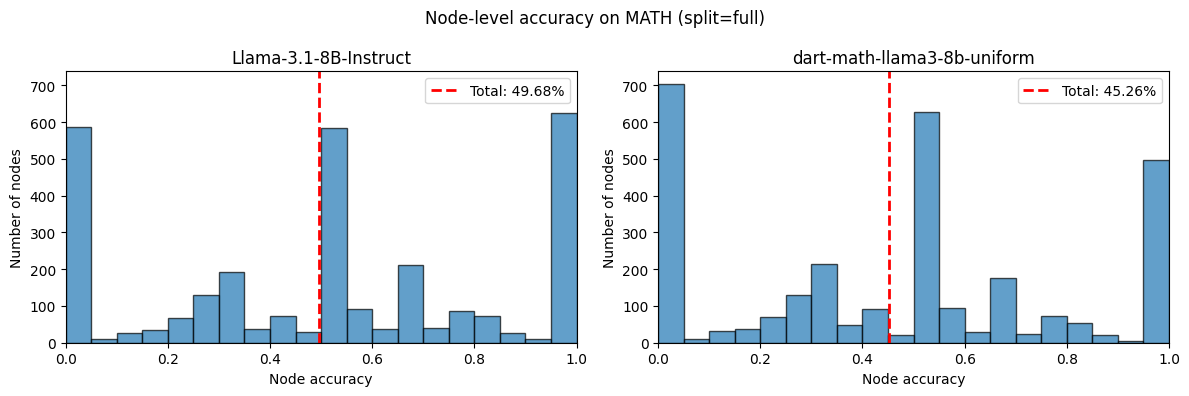

In [2]:
def collect_node_accuracies(ci_node: dict, accs: list, min_instances: int = 1) -> None:
    """Traverse CI tree; append accuracy (sum_metrics/size) for every node with size >= min_instances."""
    size = ci_node.get("size")
    sum_metrics = ci_node.get("sum_metrics")
    if size is not None and sum_metrics is not None and size > 0 and size >= min_instances:
        accs.append(sum_metrics / size)
    st = ci_node.get("subtrees")
    if st is None:
        return
    if isinstance(st, int):
        return
    if isinstance(st, list):
        for sub in st:
            collect_node_accuracies(sub, accs, min_instances)
        return
    if isinstance(st, dict):
        for sub in st.values():
            collect_node_accuracies(sub, accs, min_instances)
        return

accuracies_per_model = {m: [] for m in MODELS}
for m in MODELS:
    collect_node_accuracies(ci_trees[m], accuracies_per_model[m], min_instances=MIN_NODES)

# Total accuracy on entire benchmark (root node = full tree)
total_accuracy = {}
for m in MODELS:
    root = ci_trees[m]
    s, n = root.get("sum_metrics"), root.get("size")
    total_accuracy[m] = (s / n) if n and n > 0 else 0.0
print("Total accuracy on entire benchmark:")
for m in MODELS:
    print(f"  {m}: {total_accuracy[m]:.2%}")

bins = np.linspace(0, 1, 21)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (model, accs) in zip(axes, accuracies_per_model.items()):
    ax.hist(accs, bins=bins, edgecolor="black", alpha=0.7)
    ax.axvline(total_accuracy[model], color="red", linestyle="--", linewidth=2, label=f"Total: {total_accuracy[model]:.2%}")
    ax.set_xlabel("Node accuracy")
    ax.set_ylabel("Number of nodes")
    ax.set_title(model)
    ax.set_xlim(0, 1)
    ax.legend()
ymax = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(0, ymax)
axes[1].set_ylim(0, ymax)
plt.suptitle(f"Node-level accuracy on {BENCHMARK} (split={SPLIT})", fontsize=12)
plt.tight_layout()
plt.show()

## Superior Model for each Node (by Raw Accuracy)

Same two-panel layout as above, but only counting nodes where the model is superior are shown, where "superior" is defined by **raw node accuracy** (which model has higher mean accuracy at that node), not by non-overlap of binomial CIs.

In [3]:
def get_node_at_path(ci_root: dict, path: list) -> dict | None:
    """Return the node at the given path in the confidence_interval tree."""
    node = ci_root
    for key in path:
        st = node.get("subtrees")
        if not isinstance(st, dict) or key not in st:
            return None
        node = st[key]
    return node

def collect_all_nodes_with_path(ci_node: dict, path: list, out: list) -> list:
    """Append (path, instance_list) for every internal node (dict or list subtrees). Returns instance list."""
    st = ci_node.get("subtrees")
    if st is None:
        return []
    if isinstance(st, int):
        return [st]
    if isinstance(st, list):
        instances = []
        for sub in st:
            instances.extend(collect_all_nodes_with_path(sub, path, out))
        out.append((path, instances))
        return instances
    if isinstance(st, dict):
        all_instances = []
        for k, sub in st.items():
            all_instances.extend(collect_all_nodes_with_path(sub, path + [str(k)], out))
        if path:  # skip root
            out.append((path, all_instances))
        return all_instances
    return []


Nodes where one model has higher raw accuracy than the other:
  Total nodes (in tree): 2962
  Nodes where Llama-3.1-8B-Instruct has higher raw accuracy: 1026
  Nodes where dart-math-llama3-8b-uniform has higher raw accuracy: 559


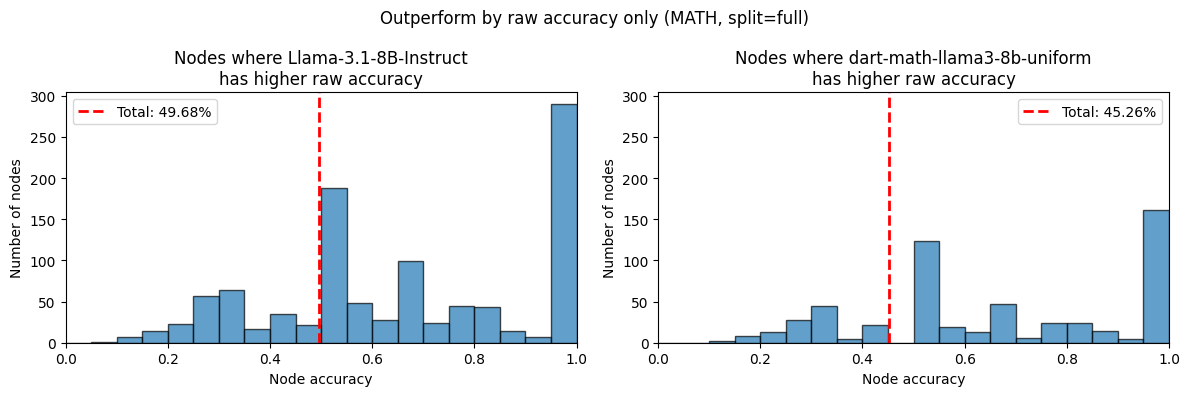

In [4]:
# Reuse node list (or rebuild)
all_node_paths_raw = []
collect_all_nodes_with_path(ci_trees[MODELS[0]], [], all_node_paths_raw)
all_node_paths_raw = [(p, inst) for p, inst in all_node_paths_raw if len(inst) >= MIN_NODES]

# Classify by raw accuracy only: which model has higher accuracy at this node?
accs_where_model0_higher_raw = []
accs_where_model1_higher_raw = []

for path, _ in all_node_paths_raw:
    node0 = get_node_at_path(ci_trees[MODELS[0]], path)
    node1 = get_node_at_path(ci_trees[MODELS[1]], path)
    if not node0 or not node1:
        continue
    n0, n1 = node0.get("size"), node1.get("size")
    if not n0 or not n1:
        continue
    acc0 = node0["sum_metrics"] / n0
    acc1 = node1["sum_metrics"] / n1
    if acc0 > acc1:
        accs_where_model0_higher_raw.append(acc0)
    elif acc1 > acc0:
        accs_where_model1_higher_raw.append(acc1)
    # tie: skip (or could assign to both; here we skip)

print("Nodes where one model has higher raw accuracy than the other:")
print(f"  Total nodes (in tree): {len(all_node_paths_raw)}")
print(f"  Nodes where {MODELS[0]} has higher raw accuracy: {len(accs_where_model0_higher_raw)}")
print(f"  Nodes where {MODELS[1]} has higher raw accuracy: {len(accs_where_model1_higher_raw)}")

bins = np.linspace(0, 1, 21)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(accs_where_model0_higher_raw, bins=bins, edgecolor="black", alpha=0.7)
axes[0].axvline(total_accuracy[MODELS[0]], color="red", linestyle="--", linewidth=2, label=f"Total: {total_accuracy[MODELS[0]]:.2%}")
axes[0].set_xlabel("Node accuracy")
axes[0].set_ylabel("Number of nodes")
axes[0].set_title(f"Nodes where {MODELS[0]}\nhas higher raw accuracy")
axes[0].set_xlim(0, 1)
axes[0].legend()

axes[1].hist(accs_where_model1_higher_raw, bins=bins, edgecolor="black", alpha=0.7)
axes[1].axvline(total_accuracy[MODELS[1]], color="red", linestyle="--", linewidth=2, label=f"Total: {total_accuracy[MODELS[1]]:.2%}")
axes[1].set_xlabel("Node accuracy")
axes[1].set_ylabel("Number of nodes")
axes[1].set_title(f"Nodes where {MODELS[1]}\nhas higher raw accuracy")
axes[1].set_xlim(0, 1)
axes[1].legend()

# Same y-axis scale for both panels
ymax = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(0, ymax)
axes[1].set_ylim(0, ymax)

plt.suptitle(f"Outperform by raw accuracy only ({BENCHMARK}, split={SPLIT})", fontsize=12)
plt.tight_layout()
plt.show()

## Superior Model for each Node (by Binomial Test CI Overlap)

Only counting nodes where the model is superior are shown, where "superior" is defined by **no overlap in Binomial Test CI**. This is the strictest standard of superiority.

Nodes with no CI overlap (one model clearly outperforms the other):
  Total nodes (in tree): 2962
  Nodes where Llama-3.1-8B-Instruct outperforms dart-math-llama3-8b-uniform: 1
  Nodes where dart-math-llama3-8b-uniform outperforms Llama-3.1-8B-Instruct: 0


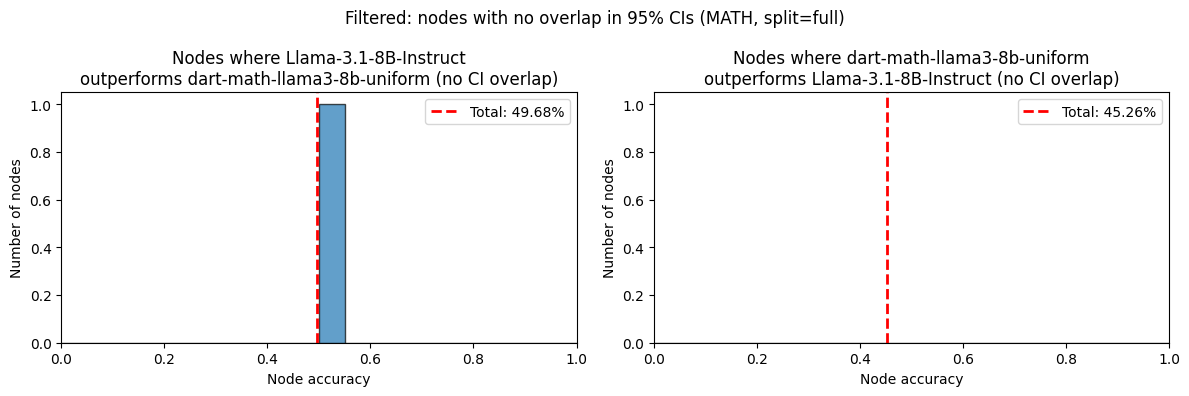

In [5]:
ALPHA = 0.05
ci_key = str(ALPHA)
all_node_paths = []
collect_all_nodes_with_path(ci_trees[MODELS[0]], [], all_node_paths)
all_node_paths = [(p, inst) for p, inst in all_node_paths if len(inst) >= MIN_NODES]

# For each node: get both models' accuracy and 95% CI; classify as model0 wins, model1 wins, or overlap
accs_where_model0_wins = []  # nodes where MODELS[0] outperforms MODELS[1] (no overlap, model0 above)
accs_where_model1_wins = []

for path, instances in all_node_paths:
    node0 = get_node_at_path(ci_trees[MODELS[0]], path)
    node1 = get_node_at_path(ci_trees[MODELS[1]], path)
    if not node0 or not node1:
        continue
    ci0 = node0.get("confidence_interval") and node0["confidence_interval"].get(ci_key)
    ci1 = node1.get("confidence_interval") and node1["confidence_interval"].get(ci_key)
    if not ci0 or not ci1 or len(ci0) != 2 or len(ci1) != 2:
        continue
    low0, high0 = float(ci0[0]), float(ci0[1])
    low1, high1 = float(ci1[0]), float(ci1[1])
    # No overlap: one interval entirely above the other
    if high1 < low0:  # model0's CI entirely above model1's -> model0 wins
        acc0 = node0["sum_metrics"] / node0["size"] if node0.get("size") else 0
        accs_where_model0_wins.append(acc0)
    elif high0 < low1:  # model1's CI entirely above model0's -> model1 wins
        acc1 = node1["sum_metrics"] / node1["size"] if node1.get("size") else 0
        accs_where_model1_wins.append(acc1)

print("Nodes with no CI overlap (one model clearly outperforms the other):")
print(f"  Total nodes (in tree): {len(all_node_paths)}")
print(f"  Nodes where {MODELS[0]} outperforms {MODELS[1]}: {len(accs_where_model0_wins)}")
print(f"  Nodes where {MODELS[1]} outperforms {MODELS[0]}: {len(accs_where_model1_wins)}")

bins = np.linspace(0, 1, 21)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(accs_where_model0_wins, bins=bins, edgecolor="black", alpha=0.7)
axes[0].axvline(total_accuracy[MODELS[0]], color="red", linestyle="--", linewidth=2, label=f"Total: {total_accuracy[MODELS[0]]:.2%}")
axes[0].set_xlabel("Node accuracy")
axes[0].set_ylabel("Number of nodes")
axes[0].set_title(f"Nodes where {MODELS[0]}\noutperforms {MODELS[1]} (no CI overlap)")
axes[0].set_xlim(0, 1)
axes[0].legend()

axes[1].hist(accs_where_model1_wins, bins=bins, edgecolor="black", alpha=0.7)
axes[1].axvline(total_accuracy[MODELS[1]], color="red", linestyle="--", linewidth=2, label=f"Total: {total_accuracy[MODELS[1]]:.2%}")
axes[1].set_xlabel("Node accuracy")
axes[1].set_ylabel("Number of nodes")
axes[1].set_title(f"Nodes where {MODELS[1]}\noutperforms {MODELS[0]} (no CI overlap)")
axes[1].set_xlim(0, 1)
axes[1].legend()

ymax = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(0, ymax)
axes[1].set_ylim(0, ymax)
plt.suptitle(f"Filtered: nodes with no overlap in 95% CIs ({BENCHMARK}, split={SPLIT})", fontsize=12)
plt.tight_layout()
plt.show()

## Save all figures (iterate benchmarks and model pairs)

Run the **Setup** cell first. This section discovers all models in each benchmark's `eval_results/real/` folder (that have a CI file for the benchmark's split), then for every **pair** of models saves:
- **Raw** node-accuracy histograms → `saved_figures/<benchmark>/<benchmark>_<model1>_vs_<model2>_raw.png` (and `.pkl`)
- **Outperforming (CI)** no-overlap histograms → `..._outperforming.png` (and `.pkl`)
- **Outperforming (raw accuracy)** histograms → `..._outperforming_raw.png` (and `.pkl`)

All two-panel figures use the same y-axis scale across the two panels.

In [6]:
SAVED_FIGURES_DIR = "saved_figures"  # under cwd (DILL repo root)

def list_models_for_benchmark(benchmark: str, split: str, evaltree_root: str) -> list[str]:
    """List model names that have confidence_interval.json for this benchmark and split."""
    real_dir = os.path.join(evaltree_root, benchmark, "eval_results", "real")
    if not os.path.isdir(real_dir):
        return []
    models = []
    for name in sorted(os.listdir(real_dir)):
        subdir = os.path.join(real_dir, name)
        if not os.path.isdir(subdir):
            continue
        path = confidence_interval_path(benchmark, name, split=split, evaltree_root=evaltree_root)
        if os.path.isfile(path):
            models.append(name)
    return models

def sanitize_for_filename(s: str) -> str:
    """Safe filename fragment: replace spaces and brackets, collapse repeated underscores."""
    s = re.sub(r"[\s\[\]\=]", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s or "unnamed"

for benchmark, split in BENCHMARK_SPLITS.items():
    models = list_models_for_benchmark(benchmark, split, EVALTREE_ROOT)
    if len(models) < 2:
        print(f"{benchmark}: skip (found {len(models)} models with CI)")
        continue
    out_dir = os.path.join(SAVED_FIGURES_DIR, benchmark)
    os.makedirs(out_dir, exist_ok=True)
    print(f"{benchmark} (split={split}): {len(models)} models → {out_dir}")

    for i in range(len(models)):
        for j in range(i + 1, len(models)):
            m1, m2 = models[i], models[j]
            try:
                tree1 = load_ci_tree(benchmark, m1, split, EVALTREE_ROOT)
                tree2 = load_ci_tree(benchmark, m2, split, EVALTREE_ROOT)
            except FileNotFoundError as e:
                print(f"  Skip {m1} vs {m2}: {e}")
                continue
            ci_trees_pair = {m1: tree1, m2: tree2}
            models_pair = [m1, m2]

            # Total accuracy
            total_acc = {}
            for m in models_pair:
                r = ci_trees_pair[m]
                s, n = r.get("sum_metrics"), r.get("size")
                total_acc[m] = (s / n) if n and n > 0 else 0.0

            # Raw histograms (only nodes with >= MIN_NODES instances)
            accs_per_model = {m: [] for m in models_pair}
            for m in models_pair:
                collect_node_accuracies(ci_trees_pair[m], accs_per_model[m], min_instances=MIN_NODES)
            bins = np.linspace(0, 1, 21)
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            for ax, (model, accs) in zip(axes, accs_per_model.items()):
                ax.hist(accs, bins=bins, edgecolor="black", alpha=0.7)
                ax.axvline(total_acc[model], color="red", linestyle="--", linewidth=2, label=f"Total: {total_acc[model]:.2%}")
                ax.set_xlabel("Node accuracy")
                ax.set_ylabel("Number of nodes")
                ax.set_title(model)
                ax.set_xlim(0, 1)
                ax.legend()
            ymax = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
            axes[0].set_ylim(0, ymax)
            axes[1].set_ylim(0, ymax)
            plt.suptitle(f"Node-level accuracy on {benchmark} (split={split})", fontsize=12)
            plt.tight_layout()
            base = f"{benchmark}_{sanitize_for_filename(m1)}_vs_{sanitize_for_filename(m2)}"
            raw_png = os.path.join(out_dir, f"{base}_raw.png")
            raw_pkl = os.path.join(out_dir, f"{base}_raw.pkl")
            fig.savefig(raw_png, dpi=150)
            with open(raw_pkl, "wb") as f:
                pickle.dump(fig, f)
            plt.close(fig)
            print(f"  Saved raw: {raw_png}")

            # Outperforming (no CI overlap) histograms
            all_paths = []
            collect_all_nodes_with_path(ci_trees_pair[m1], [], all_paths)
            all_paths = [(p, inst) for p, inst in all_paths if len(inst) >= MIN_NODES]
            accs_m1_wins = []
            accs_m2_wins = []
            ci_key = "0.05"
            for path, _ in all_paths:
                n1 = get_node_at_path(ci_trees_pair[m1], path)
                n2 = get_node_at_path(ci_trees_pair[m2], path)
                if not n1 or not n2:
                    continue
                c1 = n1.get("confidence_interval") and n1["confidence_interval"].get(ci_key)
                c2 = n2.get("confidence_interval") and n2["confidence_interval"].get(ci_key)
                if not c1 or not c2 or len(c1) != 2 or len(c2) != 2:
                    continue
                l1, h1 = float(c1[0]), float(c1[1])
                l2, h2 = float(c2[0]), float(c2[1])
                if h2 < l1:
                    accs_m1_wins.append(n1["sum_metrics"] / n1["size"] if n1.get("size") else 0)
                elif h1 < l2:
                    accs_m2_wins.append(n2["sum_metrics"] / n2["size"] if n2.get("size") else 0)
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            axes[0].hist(accs_m1_wins, bins=bins, edgecolor="black", alpha=0.7)
            axes[0].axvline(total_acc[m1], color="red", linestyle="--", linewidth=2, label=f"Total: {total_acc[m1]:.2%}")
            axes[0].set_xlabel("Node accuracy")
            axes[0].set_ylabel("Number of nodes")
            axes[0].set_title(f"Nodes where {m1}\noutperforms {m2} (no CI overlap)")
            axes[0].set_xlim(0, 1)
            axes[0].legend()
            axes[1].hist(accs_m2_wins, bins=bins, edgecolor="black", alpha=0.7)
            axes[1].axvline(total_acc[m2], color="red", linestyle="--", linewidth=2, label=f"Total: {total_acc[m2]:.2%}")
            axes[1].set_xlabel("Node accuracy")
            axes[1].set_ylabel("Number of nodes")
            axes[1].set_title(f"Nodes where {m2}\noutperforms {m1} (no CI overlap)")
            axes[1].set_xlim(0, 1)
            axes[1].legend()
            ymax = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
            axes[0].set_ylim(0, ymax)
            axes[1].set_ylim(0, ymax)
            plt.suptitle(f"Filtered: no overlap in 95% CIs ({benchmark}, split={split})", fontsize=12)
            plt.tight_layout()
            out_png = os.path.join(out_dir, f"{base}_outperforming.png")
            out_pkl = os.path.join(out_dir, f"{base}_outperforming.pkl")
            fig.savefig(out_png, dpi=150)
            with open(out_pkl, "wb") as f:
                pickle.dump(fig, f)
            plt.close(fig)
            print(f"  Saved outperforming: {out_png}")

            # Outperforming (raw accuracy only) histograms (all_paths already filtered by MIN_NODES)
            accs_m1_higher_raw = []
            accs_m2_higher_raw = []
            for path, _ in all_paths:
                n1 = get_node_at_path(ci_trees_pair[m1], path)
                n2 = get_node_at_path(ci_trees_pair[m2], path)
                if not n1 or not n2 or not n1.get("size") or not n2.get("size"):
                    continue
                acc1 = n1["sum_metrics"] / n1["size"]
                acc2 = n2["sum_metrics"] / n2["size"]
                if acc1 > acc2:
                    accs_m1_higher_raw.append(acc1)
                elif acc2 > acc1:
                    accs_m2_higher_raw.append(acc2)
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            axes[0].hist(accs_m1_higher_raw, bins=bins, edgecolor="black", alpha=0.7)
            axes[0].axvline(total_acc[m1], color="red", linestyle="--", linewidth=2, label=f"Total: {total_acc[m1]:.2%}")
            axes[0].set_xlabel("Node accuracy")
            axes[0].set_ylabel("Number of nodes")
            axes[0].set_title(f"Nodes where {m1}\nhas higher raw accuracy than {m2}")
            axes[0].set_xlim(0, 1)
            axes[0].legend()
            axes[1].hist(accs_m2_higher_raw, bins=bins, edgecolor="black", alpha=0.7)
            axes[1].axvline(total_acc[m2], color="red", linestyle="--", linewidth=2, label=f"Total: {total_acc[m2]:.2%}")
            axes[1].set_xlabel("Node accuracy")
            axes[1].set_ylabel("Number of nodes")
            axes[1].set_title(f"Nodes where {m2}\nhas higher raw accuracy than {m1}")
            axes[1].set_xlim(0, 1)
            axes[1].legend()
            ymax = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
            axes[0].set_ylim(0, ymax)
            axes[1].set_ylim(0, ymax)
            plt.suptitle(f"Nodes where one model has higher raw accuracy ({benchmark}, split={split})", fontsize=12)
            plt.tight_layout()
            raw_out_png = os.path.join(out_dir, f"{base}_outperforming_raw.png")
            raw_out_pkl = os.path.join(out_dir, f"{base}_outperforming_raw.pkl")
            fig.savefig(raw_out_png, dpi=150)
            with open(raw_out_pkl, "wb") as f:
                pickle.dump(fig, f)
            plt.close(fig)
            print(f"  Saved outperforming (raw): {raw_out_png}")

print("Done.")

MATH (split=full): 3 models → saved_figures/MATH
  Saved raw: saved_figures/MATH/MATH_Llama-3.1-8B-Instruct_vs_dart-math-llama3-8b-uniform_raw.png
  Saved outperforming: saved_figures/MATH/MATH_Llama-3.1-8B-Instruct_vs_dart-math-llama3-8b-uniform_outperforming.png
  Saved outperforming (raw): saved_figures/MATH/MATH_Llama-3.1-8B-Instruct_vs_dart-math-llama3-8b-uniform_outperforming_raw.png
  Saved raw: saved_figures/MATH/MATH_Llama-3.1-8B-Instruct_vs_gpt-4o-mini-2024-07-18_raw.png
  Saved outperforming: saved_figures/MATH/MATH_Llama-3.1-8B-Instruct_vs_gpt-4o-mini-2024-07-18_outperforming.png
  Saved outperforming (raw): saved_figures/MATH/MATH_Llama-3.1-8B-Instruct_vs_gpt-4o-mini-2024-07-18_outperforming_raw.png
  Saved raw: saved_figures/MATH/MATH_dart-math-llama3-8b-uniform_vs_gpt-4o-mini-2024-07-18_raw.png
  Saved outperforming: saved_figures/MATH/MATH_dart-math-llama3-8b-uniform_vs_gpt-4o-mini-2024-07-18_outperforming.png
  Saved outperforming (raw): saved_figures/MATH/MATH_dart-ma